In [1]:
import os
import sys
import numpy as np
import swyft
import pickle
import matplotlib.pyplot as plt
import torch
import importlib
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import LearningRateMonitor
torch.set_float32_matmul_precision('medium')
device_notebook = "cuda" if torch.cuda.is_available() else "cpu"
import wandb
import copy
from torch.multiprocessing import Pool
torch.multiprocessing.set_start_method('spawn',force=True)
torch.set_num_threads(28)
import itertools
import subprocess
from tqdm.auto import tqdm
sys.path.append('/home/gertwk/ALPs_with_SWYFT/analysis_scripts/ALP_sim')
from explim_functions import generate_expected_limits
from scipy.integrate import trapz

In [2]:
main_dir_name = "ALPs_with_SWYFT"
main_dir = os.getcwd().split(main_dir_name)[0]+main_dir_name+"/"
thesis_figs_dir = main_dir+"thesis_figures/" + os.getcwd().split("thesis_results/")[1] + "/"
os.makedirs(thesis_figs_dir,exist_ok=True)
irf_dir = main_dir+"IRFs/"
scripts_dir = main_dir+"analysis_scripts/ALP_sim/" # The directory where ALP_quick_sim.py is placed. Can be empty if it's in same folder as notebook.

In [3]:
names = ['flare0_agnostic', 'flare0_semi_informed', 'flare0_informed','flare0_confident1','flare0_confident3']
titles = ["Agnostic Prior", "Semi-Informed Prior", "Informed Prior", "Confident Prior", "CTAO Prior'"]
xlabel = "ALP mass ($m_\mathrm{a}$) / $\mathrm{neV}$"
ylabel = "Photon-ALP coupling ($g_{\mathrm{a}\gamma}$) / $10^{-11} \mathrm{GeV}^{-1}$"
colors_priors = ['r','#FFA500','y','g','b', ]

In [4]:
priors = {}
for ip, name in enumerate(names):

    priors[name] = {'name': name}

    priors[name]['results_path'] = '/home/gertwk/ALPs_with_SWYFT/cluster_runs/analysis_results/'+name

    priors[name]['store_path'] = priors[name]['results_path']+"/sim_output/store"

    priors[name]['config_vars'] = priors[name]['results_path'] +'/config_variables.pickle'

    priors[name]['config_phys'] = priors[name]['results_path'] +'/physics_variables.pickle'
    
    priors[name]['truncation_record'] = priors[name]['results_path'] +'/truncation_record.pickle'

    removed_ALP_sim=0
    try:
        sys.path.remove('/home/gertwk/ALPs_with_SWYFT/analysis_scripts/ALP_sim')
        removed_ALP_sim=1
    except ValueError:
        pass
    try:
        del sys.modules['ALP_quick_sim']
    except KeyError:
        pass
    sys.path.append(priors[name]['results_path'])
    import param_function
    import ALP_quick_sim
    with open(priors[name]['config_vars'], 'rb') as file: config_objects = pickle.load(file)
    for key in config_objects.keys(): priors[name][key] = config_objects[key]
    with open(priors[name]['config_phys'], 'rb') as file: config_objects = pickle.load(file)
    for key in config_objects.keys(): priors[name][key] = config_objects[key]
    with open(priors[name]['truncation_record'], 'rb') as file: config_objects = pickle.load(file)
    for key in config_objects.keys(): priors[name][key] = config_objects[key]
    sys.path.remove(priors[name]['results_path'])
    sys.path.append(priors[name]['results_path']+'/train_output/net')
    import network
    sys.path.remove(priors[name]['results_path']+'/train_output/net')
    
    count = 0
    for combo in itertools.product(*priors[name]['hyperparams'].values()):
        if count == priors[name]['which_grid_point']:
            hyperparams_point = {}
            for i, key in enumerate(priors[name]['hyperparams'].keys()):
                hyperparams_point[key]=combo[i]
        count +=1
        
    priors[name]['net_path'] = (priors[name]['results_path'] + '/train_output/net/trained_network_round_'
                                +str(priors[name]['which_truncation'])+'_gridpoint_'+str(priors[name]['which_grid_point'])+'.pt')

    priors[name]['net'] = network.NetworkCorner(nbins=priors[name]['A'].nbins, marginals=priors[name]['POI_indices'], 
                                                param_names=priors[name]['A'].param_names, **hyperparams_point)

    priors[name]['net'].load_state_dict(torch.load(priors[name]['net_path']))

    # with open(priors[name]['results_path']+'/explim_predictions.pickle', 'rb') as file:
    #     priors[name]['predictions'] = pickle.load(file)

    if priors[name]['which_truncation'] > 0:
        store_explim = swyft.ZarrStore(priors[name]['store_path'] + "/" + priors[name]['store_name']+"_explim_round_"+str(priors[name]['which_truncation'])+"_gridpoint_"+str(priors[name]['which_grid_point']))
        store_prior = swyft.ZarrStore(priors[name]['store_path'] + "/" + priors[name]['store_name']+"_prior_round_"+str(priors[name]['which_truncation'])+"_gridpoint_"+str(priors[name]['which_grid_point']))
    else:
        store_explim = swyft.ZarrStore(priors[name]['store_path'] + "/" + priors[name]['store_name']+"_explim")
        store_prior = swyft.ZarrStore(priors[name]['store_path'] + "/" + priors[name]['store_name']+"_prior")
    priors[name]['samples_explim'] = store_explim.get_sample_store()
    priors[name]['samples_prior'] = store_prior.get_sample_store()

 
    del sys.modules['param_function']
    del sys.modules['ALP_quick_sim']
    del sys.modules['network']
    if removed_ALP_sim: sys.path.append('/home/gertwk/ALPs_with_SWYFT/analysis_scripts/ALP_sim')


/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


In [5]:
trainer = swyft.SwyftTrainer(accelerator = 'cuda', precision = 64,logger=False,)

/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/gertwk/.conda/envs/swyft4-dev-notebook/lib/pyt ...
  rank_zero_warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [6]:
contour_matrices = {}
exclusion_areas = {}

In [7]:
# del sys.modules['explim_functions']
# from explim_functions import generate_expected_limits

In [8]:
colors=['b','g','y','#FFA500','r','k','k','k']
line_colors=['b','g','#FFA500','r','b']
linestyles = [':','-.','--','-','-']

In [9]:
np.random.randint(90, size=(8))

array([60, 27, 32, 25, 55, 86, 61, 45])

In [93]:
A.bin_centers[57]

764.9538622710779

In [96]:
A.counts_obs['y'][57]

-0.027972441

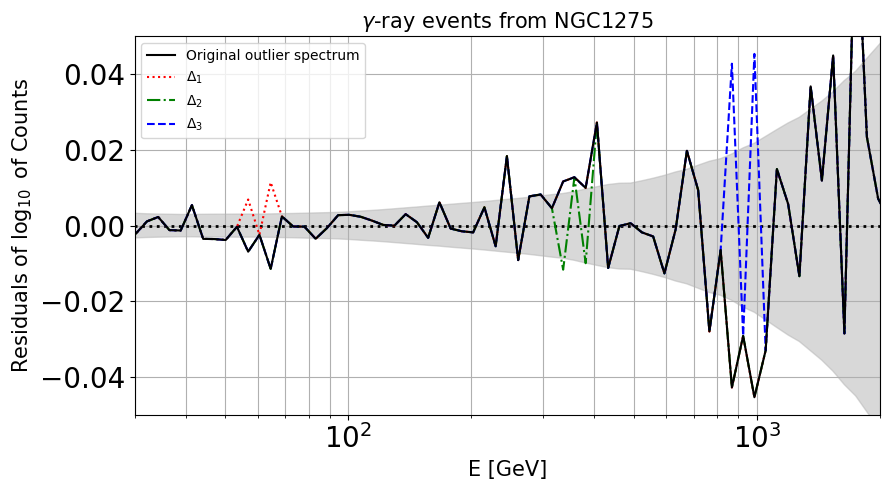

In [59]:
name = 'flare0_semi_informed'

A = priors[name]['A']
A._legend_loc = None

samples = copy.deepcopy(priors[name]['samples_explim'])

ilists = [
    [16,18],
    [44,46],
    [59,61],
    [12,14,16,43,45],
    [43,45,58,60,62],
    [12,14,16,58,60,62],
    [12,14,16,43,45,58,60,62],
    # np.random.randint(90, size=(8))
]
observations = [copy.deepcopy(samples[83])]
for j, ilist in enumerate(ilists):
    observations.append(copy.deepcopy(samples[83]))
    for i in ilist:
        observations[-1]['data'][i] = -observations[-1]['data'][i]

colors_deltas = ['r','g','b','k']
linestyles_deltas = [':','-.','--','-']
labels = [
    "$\Delta_1$",
    "$\Delta_2$",
    "$\Delta_3$",
    "Original outlier spectrum",
]
A.configure_plot(ymin=-0.05, ymax =0.05, xmin=3e1, xmax = 2e3, logx =True)
for j,i in enumerate([1,2,3,0]):
    A.configure_model(params=observations[i]['params'])
    A.import_counts(obs=observations[i]['data'],exp=observations[i]['exp'])
    new_fig = 1 if j == 0 else 0
    A.compute_case(new_fig=new_fig,new_counts=0,color='k',color_obs=colors_deltas[j],linestyle_obs=linestyles_deltas[j],
                   label_exp=0,label_obs=labels[j],linestyle=':',errorbands=new_fig, errors=0, plot_exp=new_fig)
    # A.compute_case(new_fig=0,new_counts=0,color=colors[i],color_obs=colors[i],linestyle=":",label_exp=0,label_obs=0,
    #                     errorbands=0, errors=0, plot_obs=0)

lines = A.fig.axes[-1].lines
A.fig.axes[-1].legend(
    [lines[4],lines[1],lines[2],lines[3]], 
    [lines[4]._label,lines[1]._label,lines[2]._label,lines[3]._label]
)

A.fig.tight_layout()

In [60]:
# A.fig.savefig(thesis_figs_dir+"outlier_spectrum_with_deltas.jpg")

In [18]:
logratios = []
for i,obs in enumerate(observations[1:]):
    new_logratios = trainer.infer(
        priors[name]['net'],
        obs,
        priors[name]['samples_prior'],
    )
    logratios.append(new_logratios)


/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/gertwk/.conda/envs/swyft4-dev-notebook/lib/pyt ...
  rank_zero_warn(
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packages/pytorch_lightning/loops/epoch/prediction_epoch_loop.py:173: UserWarning: Lightning couldn't infer the indices fetched for your dataloader.
  warning_cache.warn("Lightning couldn't infer the indices fetched for your dataloader.")
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

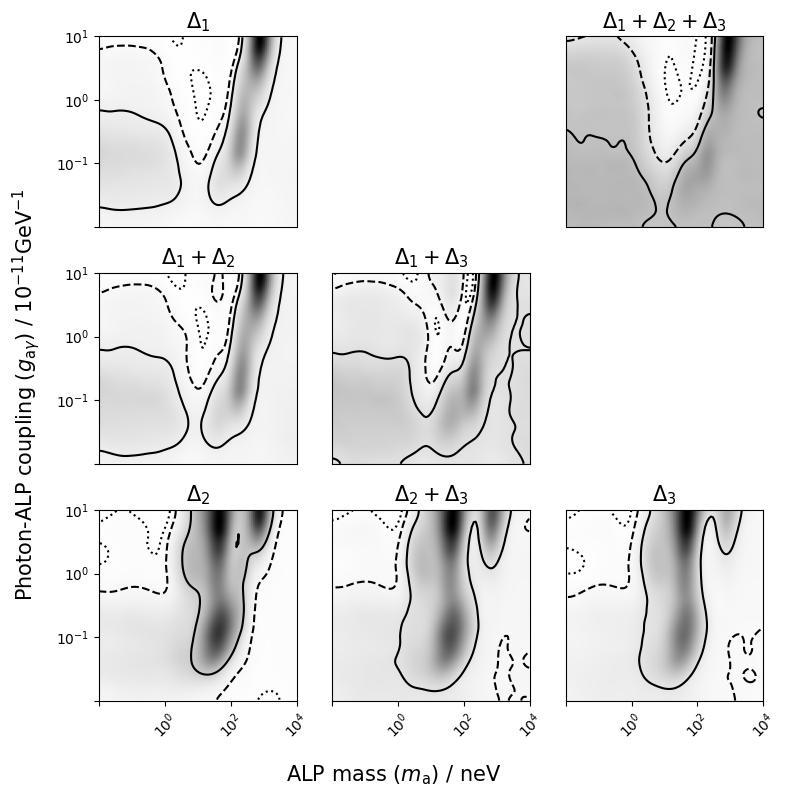

In [61]:
title_size = 15
fig = plt.figure(figsize=(8,8))
fig.add_subplot(3,3,1)
fig.axes[-1].set_title('$\Delta_1$', fontsize=title_size)
fig.add_subplot(3,3,7)
fig.axes[-1].set_title('$\Delta_2$', fontsize=title_size)
fig.add_subplot(3,3,9)
fig.axes[-1].set_title('$\Delta_3$', fontsize=title_size)
fig.add_subplot(3,3,4)
fig.axes[-1].set_title('$\Delta_1+\Delta_2$', fontsize=title_size)
fig.add_subplot(3,3,8)
fig.axes[-1].set_title('$\Delta_2+\Delta_3$', fontsize=title_size)
fig.add_subplot(3,3,5)
fig.axes[-1].set_title('$\Delta_1+\Delta_3$', fontsize=title_size)
fig.add_subplot(3,3,3)
fig.axes[-1].set_title('$\Delta_1+\Delta_2+\Delta_3$', fontsize=title_size)


axis_ticksize=10
for i,obs in enumerate(observations[1:]):
    swyft.plot.plot._plot_2d(
        logratios[i],
        A.param_names[0],
        A.param_names[1],
        color='k',
        # color_truth=colors_truth[j],
        # linestyle_truth = linestyles_truth[j],
        smooth=3,
        truth=None, #{A.param_names[i]:data[j]['params'][i] for i in POIs},
        ax = fig.axes[i]
        )

    if i not in [1,2,4]:
        fig.axes[i].set_xticks([])
    else:
        fig.axes[i].set_xticks([-2,0,2,4])
        fig.axes[i].set_xticklabels(['','$10^{0}$','$10^{2}$','$10^{4}$'],rotation=45,fontsize=axis_ticksize)
    if i not in [0,1,3]:
        fig.axes[i].set_yticks([])
    else:
        fig.axes[i].set_yticks([-2,-1,0,1])
        fig.axes[i].set_yticklabels(['','$10^{-1}$','$10^{0}$','$10^{1}$'],fontsize=axis_ticksize)
    # if i%len_names == len_names-1:
    #     noise_realization +=1
    #     fig.axes[i].set_ylabel('Noise Realization '+str(noise_realization), labelpad = 14)
    #     fig.axes[i].yaxis.set_label_position('right')

suplabel_size = 15
fig.supxlabel(xlabel, fontsize=suplabel_size)
fig.supylabel(ylabel, fontsize=suplabel_size)
fig.tight_layout()

In [62]:
# fig.savefig(thesis_figs_dir+"outlier_posterior_with_deltas.jpg")

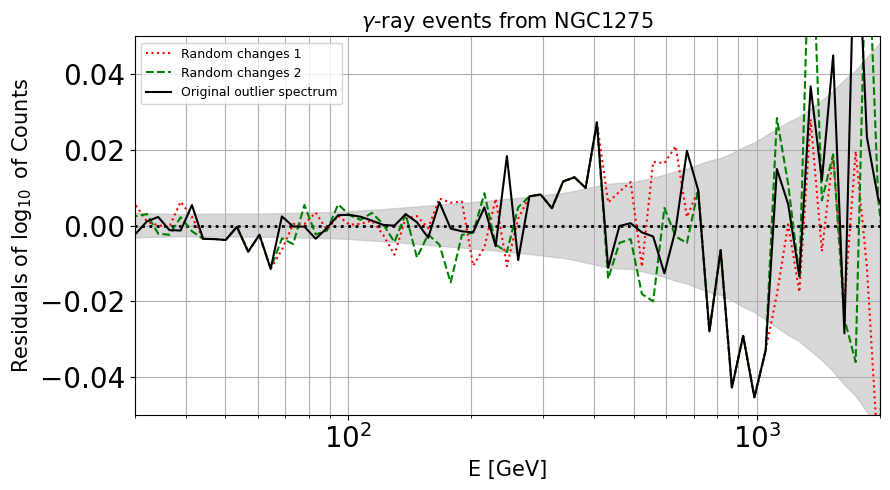

In [67]:
name = 'flare0_semi_informed'

A = priors[name]['A']

samples = copy.deepcopy(priors[name]['samples_explim'])

bins_to_choose_from = [ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 48, 49, 50,
       51, 52, 53, 54, 55, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89]

np.random.seed(1)
ilists = [
    np.random.choice(bins_to_choose_from,69,replace=False),
    np.random.choice(bins_to_choose_from,69,replace=False),
]
dummy_observations = [85,86]

observations = [copy.deepcopy(samples[83])]
for j, ilist in enumerate(ilists):
    observations.append(copy.deepcopy(samples[83]))
    dummy_observation = copy.deepcopy(samples[dummy_observations[j]])
    for i in ilist:
        observations[-1]['data'][i] = dummy_observation['data'][i]

colors_deltas = ['r','g','k']
linestyles_deltas = [':','--','-']
labels = [
    "Random changes 1",
    "Random changes 2",
    "Original outlier spectrum",
]
A.configure_plot(ymin=-0.05, ymax =0.05, xmin=3e1, xmax = 2e3, logx =True)
for j,i in enumerate([1,2,0]):
    A.configure_model(params=observations[i]['params'])
    A.import_counts(obs=observations[i]['data'],exp=observations[i]['exp'])
    new_fig = 1 if j == 0 else 0
    A.compute_case(new_fig=new_fig,new_counts=0,color='k',color_obs=colors_deltas[j],linestyle_obs=linestyles_deltas[j],label_exp=0,label_obs=labels[j],
                   linestyle=':',errorbands=new_fig, errors=0, plot_exp=new_fig)
    # A.compute_case(new_fig=0,new_counts=0,color=colors[i],color_obs=colors[i],linestyle=":",label_exp=0,label_obs=0,
    #                     errorbands=0, errors=0, plot_obs=0) 

A.fig.tight_layout()

In [68]:
# A.fig.savefig(thesis_figs_dir+"outlier_spectrum_with_random_changes.jpg")

In [69]:
logratios2 = []
for i,obs in enumerate(observations):
    new_logratios = trainer.infer(
        priors[name]['net'],
        obs,
        priors[name]['samples_prior'],
    )
    logratios2.append(new_logratios)

/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/gertwk/.conda/envs/swyft4-dev-notebook/lib/pyt ...
  rank_zero_warn(
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

In [70]:
len(bins_to_choose_from)

69

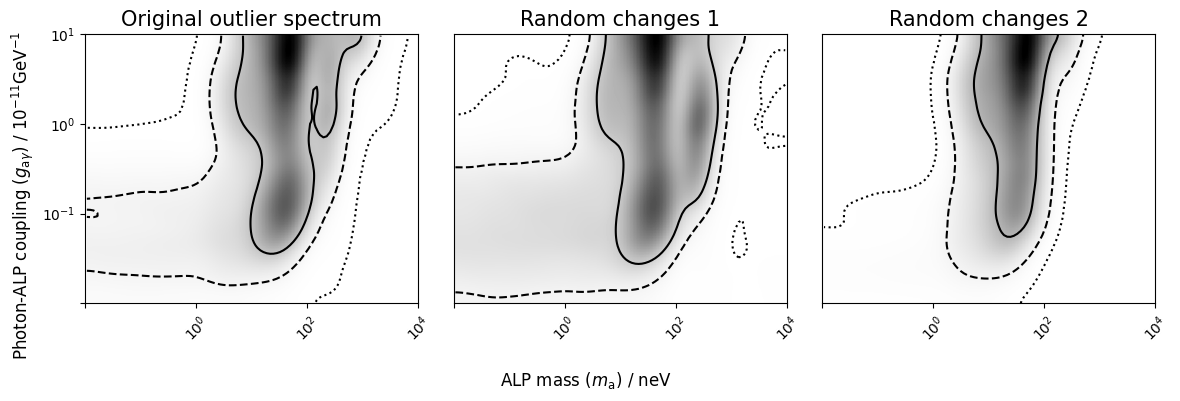

In [73]:
title_size = 15
fig = plt.figure(figsize=(12,4))
fig.add_subplot(1,3,1)
fig.axes[-1].set_title('Original outlier spectrum', fontsize=title_size)
fig.add_subplot(1,3,2)
fig.axes[-1].set_title('Random changes 1', fontsize=title_size)
fig.add_subplot(1,3,3)
fig.axes[-1].set_title('Random changes 2', fontsize=title_size)



axis_ticksize=10
for i,obs in enumerate(observations):
    swyft.plot.plot._plot_2d(
        logratios2[i],
        A.param_names[0],
        A.param_names[1],
        color='k',
        # color_truth=colors_truth[j],
        # linestyle_truth = linestyles_truth[j],
        smooth=3,
        truth=None, #{A.param_names[i]:data[j]['params'][i] for i in POIs},
        ax = fig.axes[i]
        )

    if i not in [0,1,2]:
        fig.axes[i].set_xticks([])
    else:
        fig.axes[i].set_xticks([-2,0,2,4])
        fig.axes[i].set_xticklabels(['','$10^{0}$','$10^{2}$','$10^{4}$'],rotation=45,fontsize=axis_ticksize)
    if i not in [0]:
        fig.axes[i].set_yticks([])
    else:
        fig.axes[i].set_yticks([-2,-1,0,1])
        fig.axes[i].set_yticklabels(['','$10^{-1}$','$10^{0}$','$10^{1}$'],fontsize=axis_ticksize)
    # if i%len_names == len_names-1:
    #     noise_realization +=1
    #     fig.axes[i].set_ylabel('Noise Realization '+str(noise_realization), labelpad = 14)
    #     fig.axes[i].yaxis.set_label_position('right')

suplabel_size = 12
fig.supxlabel(xlabel, fontsize=suplabel_size)
fig.supylabel(ylabel, fontsize=suplabel_size)
fig.tight_layout()

In [74]:
# fig.savefig(thesis_figs_dir+"outlier_posterior_with_random_changes.jpg")